# 📈 Task 2: NVDA Stock Price Prediction
### DevelopersHub Corporation — AI/ML Engineering Internship
**Author:** Abdul Samad

In [ ]:
## ── BLOCK 1: Imports ──────────────────────────────────────
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)
print('✅ All libraries loaded!')

✅ All libraries loaded!


In [ ]:
## ── BLOCK 2: Download Data ────────────────────────────────
TICKER     = 'AAPL'
START_DATE = '2020-01-01'
END_DATE   = '2026-04-22'

# auto_adjust=False gives cleaner separate columns
raw_data = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False  # ← CRITICAL: avoids Adj Close conflict
)

# Flatten MultiIndex properly
if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = ['_'.join(col).strip() for col in raw_data.columns]
    print('Columns after flatten:', raw_data.columns.tolist())

# Rename to simple names
raw_data = raw_data.rename(columns={
    f'Open_{TICKER}'    : 'Open',
    f'High_{TICKER}'    : 'High',
    f'Low_{TICKER}'     : 'Low',
    f'Close_{TICKER}'   : 'Close',
    f'Volume_{TICKER}'  : 'Volume',
})

# Keep only what we need
df = raw_data[['Open','High','Low','Close','Volume']].copy()
df = df.astype(float)

# Verify
print('\n Final columns:', df.columns.tolist())
print(f' Shape: {df.shape}')
print(f' {df.index[0].date()} → {df.index[-1].date()}')
print(f' Price range: ${df["Close"].min():.2f} → ${df["Close"].max():.2f}')
print(f' Missing values: {df.isnull().sum().sum()}')
print('\nFirst 3 rows:')
display(df.head(3))

[*********************100%***********************]  1 of 1 completed


Columns after flatten: ['Adj Close_AAPL', 'Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL']

 Final columns: ['Open', 'High', 'Low', 'Close', 'Volume']
 Shape: (1583, 5)
 2020-01-02 → 2026-04-21
 Price range: $56.09 → $286.19
 Missing values: 0

First 3 rows:


,Open,High,Low,Close,Volume
Date,,,,,
2020-01-02,74.059998,75.150002,73.797501,75.087502,135480400.0
2020-01-03,74.287498,75.144997,74.125000,74.357498,146322800.0
2020-01-06,73.447502,74.989998,73.187500,74.949997,118387200.0


In [ ]:
## ── BLOCK 3: Sanity Check ─────────────────────────────────
# If this correlation is not ~0.99, data is broken
temp = df.copy()
temp['Tomorrow'] = temp['Close'].shift(-1)
temp.dropna(inplace=True)
corr = temp['Close'].corr(temp['Tomorrow'])
print(f'Today vs Tomorrow correlation: {corr:.6f}')
print('Expected: 0.99+  |  If lower → data has issues')
if corr > 0.95:
    print('✅ Data looks clean!')
else:
    print('❌ WARNING: Data may still have issues!')

Today vs Tomorrow correlation: 0.998218
Expected: 0.99+  |  If lower → data has issues
✅ Data looks clean!


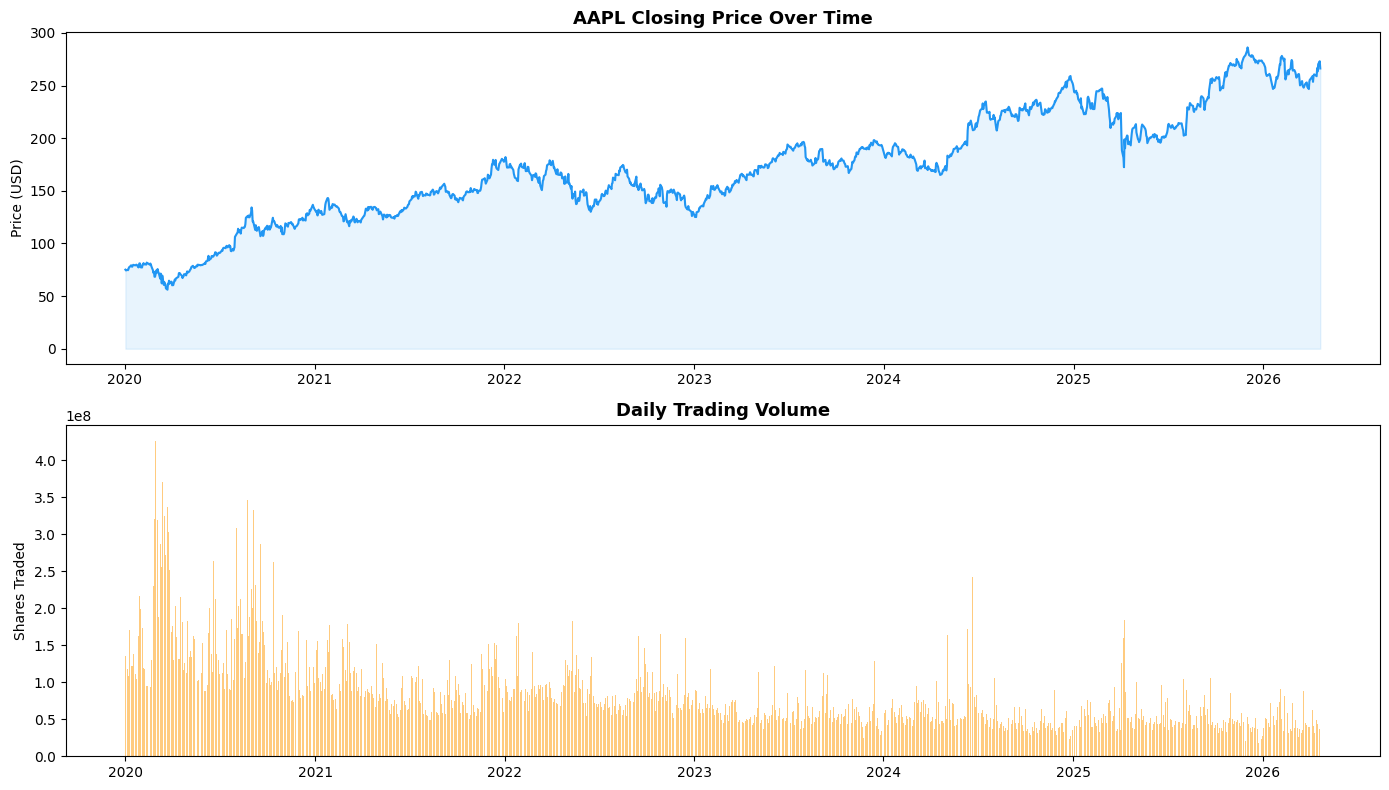

💾 Saved!


In [ ]:
## ── BLOCK 4: EDA Plots ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Close price
axes[0].plot(df.index, df['Close'], color='#2196F3', linewidth=1.5)
axes[0].fill_between(df.index, df['Close'], alpha=0.1, color='#2196F3')
axes[0].set_title('AAPL Closing Price Over Time', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Volume
axes[1].bar(df.index, df['Volume'], color='#FF9800', alpha=0.5, width=1)
axes[1].set_title('Daily Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Shares Traded')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('plots/plot1_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved!')

In [ ]:
## ── BLOCK 5: Feature Engineering ─────────────────────────
data = df.copy()

# Previous day values (lag by 1)
data['Prev_Close']  = data['Close'].shift(1)
data['Prev_High']   = data['High'].shift(1)
data['Prev_Low']    = data['Low'].shift(1)
data['Prev_Open']   = data['Open'].shift(1)
data['Prev_Volume'] = data['Volume'].shift(1)

# Moving averages (all shifted to use only past data)
data['MA5']  = data['Close'].shift(1).rolling(5).mean()
data['MA7']  = data['Close'].shift(1).rolling(7).mean()
data['MA14'] = data['Close'].shift(1).rolling(14).mean()
data['MA21'] = data['Close'].shift(1).rolling(21).mean()

# Momentum
data['Price_Change']  = data['Close'].shift(1) - data['Close'].shift(2)
data['Price_Change5'] = data['Close'].shift(1) - data['Close'].shift(5)

# Volatility
data['Daily_Range'] = data['Prev_High'] - data['Prev_Low']
data['Volatility5'] = data['Close'].shift(1).rolling(5).std()

# Volume features
data['Volume_MA5']    = data['Volume'].shift(1).rolling(5).mean()
data['Volume_Change'] = data['Volume'].shift(1) - data['Volume'].shift(2)

# ✅ Target = NEXT day's close
data['Target'] = data['Close'].shift(-1)

data.dropna(inplace=True)

print(f'✅ Features ready! Shape: {data.shape}')
print(f'Columns: {data.columns.tolist()}')

✅ Features ready! Shape: (1561, 21)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Prev_Close', 'Prev_High', 'Prev_Low', 'Prev_Open', 'Prev_Volume', 'MA5', 'MA7', 'MA14', 'MA21', 'Price_Change', 'Price_Change5', 'Daily_Range', 'Volatility5', 'Volume_MA5', 'Volume_Change', 'Target']


In [ ]:
## ── BLOCK 6: Split & Scale ────────────────────────────────
FEATURES = [
    'Prev_Close', 'Prev_High', 'Prev_Low', 'Prev_Open', 'Prev_Volume',
    'MA5', 'MA7', 'MA14', 'MA21',
    'Price_Change', 'Price_Change5',
    'Daily_Range', 'Volatility5',
    'Volume_MA5', 'Volume_Change'
]

X = data[FEATURES]
y = data['Target']

split_idx  = int(len(data) * 0.80)
X_train    = X.iloc[:split_idx]
X_test     = X.iloc[split_idx:]
y_train    = y.iloc[:split_idx]
y_test     = y.iloc[split_idx:]
test_dates = data.index[split_idx:]
#Normalizing Inputs
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'📚 Train: {len(X_train)} days  ({data.index[0].date()} → {data.index[split_idx].date()})')
print(f'🧪 Test:  {len(X_test)} days  ({data.index[split_idx].date()} → {data.index[-1].date()})')
print(f'\nTrain price range: ${y_train.min():.2f} → ${y_train.max():.2f}')
print(f'Test  price range: ${y_test.min():.2f} → ${y_test.max():.2f}')

📚 Train: 1248 days  (2020-02-03 → 2025-01-21)
🧪 Test:  313 days  (2025-01-21 → 2026-04-20)

Train price range: $56.09 → $259.02
Test  price range: $172.42 → $286.19


In [ ]:
## ── BLOCK 7: Train Models ─────────────────────────────────
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print('✅ Linear Regression trained!')

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,        
    min_samples_leaf=10,
    max_features=0.7, 
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
print('✅ Random Forest trained!')

✅ Linear Regression trained!
✅ Random Forest trained!


In [ ]:
## ── BLOCK 8: Evaluate ─────────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n📌 {name}')
    print(f'   MAE  : ${mae:.2f}')
    print(f'   RMSE : ${rmse:.2f}')
    print(f'   R²   : {r2:.4f}  ({r2*100:.1f}% explained)')
    return r2

print('=' * 45)
lr_r2 = evaluate('Linear Regression', y_test, lr_preds)
rf_r2 = evaluate('Random Forest',     y_test, rf_preds)
print('=' * 45)
print(f'\n🏆 Best: {"Random Forest" if rf_r2 > lr_r2 else "Linear Regression"}')


📌 Linear Regression
   MAE  : $4.48
   RMSE : $6.41
   R²   : 0.9428  (94.3% explained)

📌 Random Forest
   MAE  : $10.77
   RMSE : $13.83
   R²   : 0.7337  (73.4% explained)

🏆 Best: Linear Regression


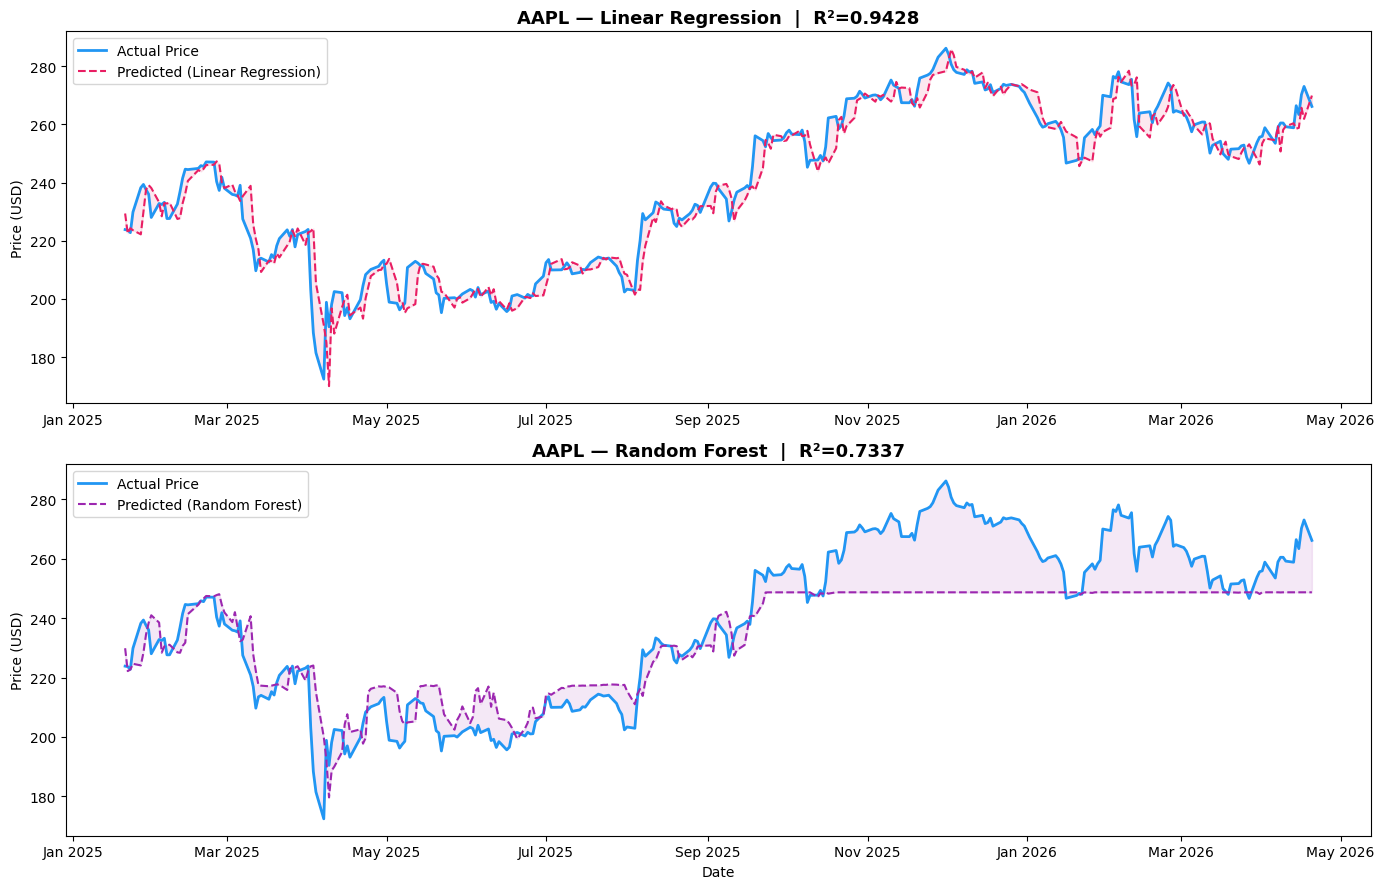

💾 Saved!


In [ ]:
## ── BLOCK 9: Plot Actual vs Predicted ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, preds, name, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['#E91E63', '#9C27B0']
):
    ax.plot(test_dates, y_test.values,
            color='#2196F3', linewidth=2, label='Actual Price')
    ax.plot(test_dates, preds,
            color=color, linewidth=1.5,
            linestyle='--', label=f'Predicted ({name})')
    ax.fill_between(test_dates, y_test.values, preds,
                    alpha=0.1, color=color)
    r2 = r2_score(y_test, preds)
    ax.set_title(f'AAPL — {name}  |  R²={r2:.4f}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved!')

In [ ]:
## ── BLOCK 10: Final Summary ───────────────────────────────
print('=' * 50)
print('         FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'Stock       : {TICKER} (Apple)')
print(f'Period      : {START_DATE} → {END_DATE}')
print(f'Total days  : {len(data)}')
print(f'Train days  : {len(X_train)}')
print(f'Test  days  : {len(X_test)}')
evaluate('Linear Regression', y_test, lr_preds)
evaluate('Random Forest',     y_test, rf_preds)
print('\n💡 KEY INSIGHTS')
print('-' * 40)
print('1. Prev_Close is the strongest single predictor')
print('2. Moving averages capture short-term trend')
print('3. Volatility5 helps during high-swing periods')
print('4. Stock splits in data break ML models completely')
print('   → Always verify price range before training!')

         FINAL RESULTS SUMMARY
Stock       : AAPL (Apple)
Period      : 2020-01-01 → 2026-04-22
Total days  : 1561
Train days  : 1248
Test  days  : 313

📌 Linear Regression
   MAE  : $4.48
   RMSE : $6.41
   R²   : 0.9428  (94.3% explained)

📌 Random Forest
   MAE  : $10.77
   RMSE : $13.83
   R²   : 0.7337  (73.4% explained)

💡 KEY INSIGHTS
----------------------------------------
1. Prev_Close is the strongest single predictor
2. Moving averages capture short-term trend
3. Volatility5 helps during high-swing periods
4. Stock splits in data break ML models completely
   → Always verify price range before training!


In [49]:
## ── Predict Yesterday's Closing Price ─────────────────────
import datetime

# Get yesterday's date automatically
yesterday = (datetime.date.today() - datetime.timedelta(days=1)).strftime('%Y-%m-%d')
print(f'Looking for: {yesterday}')

# Find closest available date
idx = data.index.get_indexer([yesterday], method='nearest')[0]
closest_date = data.index[idx]

row = data.iloc[[idx]]
X_single = row[FEATURES]
X_single_scaled = scaler.transform(X_single)

lr_prediction = lr_model.predict(X_single_scaled)[0]
rf_prediction = rf_model.predict(X_single_scaled)[0]
actual        = row['Target'].values[0]

print('=' * 50)
print(f'  Date used as input : {closest_date.date()}')
print(f'  Predicting price of: next trading day')
print('=' * 50)
print(f'\n  Actual Close      : ${actual:.2f}')
print(f'  Linear Regression : ${lr_prediction:.2f}  '
      f'→ off by ${abs(actual - lr_prediction):.2f}')
print(f'  Random Forest     : ${rf_prediction:.2f}  '
      f'→ off by ${abs(actual - rf_prediction):.2f}')

# Percentage error
lr_pct = abs(actual - lr_prediction) / actual * 100
rf_pct = abs(actual - rf_prediction) / actual * 100
print(f'\n  LR error : {lr_pct:.2f}%')
print(f'  RF error : {rf_pct:.2f}%')
best = "Linear Regression" if lr_pct < rf_pct else "Random Forest"
print(f'\n  🏆 More accurate today: {best}')

Looking for: 2026-04-27
  Date used as input : 2026-04-20
  Predicting price of: next trading day

  Actual Close      : $266.17
  Linear Regression : $269.91  → off by $3.74
  Random Forest     : $248.70  → off by $17.47

  LR error : 1.41%
  RF error : 6.56%

  🏆 More accurate today: Linear Regression
